<a href="https://colab.research.google.com/github/UdayKajana/udaykajana-codeforge/blob/machine_learnings/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Basics**

---



## ***RAG Implementation***

-------



In [ ]:
# 📦 INSTALLS
!pip install -q openai chromadb pypdf tiktoken ipywidgets

In [ ]:
# 📚 IMPORTS
import uuid
import textwrap
#----------------------------------------
from google.colab import files
from google.colab import userdata
#----------------------------------------
from openai import OpenAI
from pypdf import PdfReader
#----------------------------------------
import chromadb

# 🔑 OPENAI CLIENT
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = OpenAI( api_key= OPENAI_API_KEY)

# 📄 LOAD PDF
def load_pdf(pdf_path):
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        extracted = page.extract_text()
        if extracted:
            text += extracted + "\n"
    return text

# ✂️ CHUNKER WITH OVERLAP
def chunk_text(text, chunk_size=1000, overlap=200):
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        # move forward with overlap
        start += chunk_size - overlap
    return chunks

# 🧠 CREATE EMBEDDING
def get_embedding(text):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    return response.data[0].embedding

# 🗂️ CHROMADB SETUP
chroma_client = chromadb.Client()
collection = chroma_client.get_or_create_collection(
    name="simple_rag"
)

# 📥 STORE CHUNKS
def add_chunks_to_chroma(chunks):
    for chunk in chunks:
        embedding = get_embedding(chunk)
        collection.add(
            ids=[str(uuid.uuid4())],
            documents=[chunk],
            embeddings=[embedding]
        )

    print(f"Stored {len(chunks)} chunks in ChromaDB.")


# 🔎 RETRIEVE DOCUMENTS
def retrieve(query, top_k=3):
    query_embedding = get_embedding(query)
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k
    )
    docs = results["documents"][0]
    return docs

# 🤖 ASK QUESTION
def ask(query):
    docs = retrieve(query)
    context = "\n\n".join(docs)
    prompt = f"""
    You are a helpful RAG assistant.
    Answer ONLY from the provided context.
    If the answer is not in the context, say:
    "I could not find the answer in the document."
    Context:
    {context}
    Question:
    {query}
    """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": "You answer questions using retrieved documents."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.2
    )

    return response.choices[0].message.content

# 📂 UPLOAD PDF
print("Upload your PDF file.\n")
uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]
print(f"\nLoaded PDF: {pdf_path}")

# 🏗️ BUILD RAG PIPELINE
print("\nLoading PDF...")
text = load_pdf(pdf_path)
print("PDF loaded.")
print("\nChunking document...")
chunks = chunk_text(text, chunk_size=800, overlap=200)
print(f"Created {len(chunks)} chunks.")
print("\nGenerating embeddings and storing in ChromaDB...")
add_chunks_to_chroma(chunks)
print("\n✅ RAG Pipeline Ready")

# 💬 INTERACTIVE CHATBOT
print("\n🤖 Chatbot Ready")
print("Type 'exit' to stop.\n")
while True:
    query = input("You: ")
    if query.lower() == "exit":
        print("\nBot: Goodbye.")
        break
    answer = ask(query)
    print("\nBot:")
    print(textwrap.fill(answer, width=100))
    print("\n" + "=" * 100 + "\n")

TypeError: 'NoneType' object is not subscriptable

## ***Embeddings for Sentances***

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
sentences = ["This is an example sentence", "Each sentence is converted"]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(embeddings)

## ***Chunking Strategies***
Stack: OpenAI gpt-4o-mini + text-embedding-3-small | ChromaDB | 5 Chunking Strategies

---
Strategies: Fixed-Size Character | Recursive Character | Token-Based | Sentence-Based | Semantic

Workflow: PDF -> Extract -> Chunk -> Embed -> ChromaDB -> Retrieve -> GPT-4o-mini -> Answer






### 1. Setup to load the files and extract text for chunking

In [ ]:
#-----------------------------------------------------
# 2.INSTALL
!pip install -q openai chromadb pypdf langchain langchain-openai langchain-community tiktoken nltk
!pip install -q langchain langchain-text-splitters

#-----------------------------------------------------
# 2.IMPORT STATEMENTS
import os
import textwrap
import warnings
import numpy as np
import nltk
from typing import List, Dict, Any, Optional
import chromadb
from pypdf import PdfReader
import tiktoken
from openai import OpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('All imports loaded.')

#-----------------------------------------------------
# 3.API Key and Model Settings
import os
from google.colab import userdata

# Option A: Colab Secrets (recommended) # Option B: paste directly # os.environ['OPENAI_API_KEY'] = 'sk-...'
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

CHAT_MODEL  = 'gpt-4o-mini'
EMBED_MODEL = 'text-embedding-3-small'
TOP_K       = 4

client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])
print(f'Chat model  : {CHAT_MODEL}')
print(f'Embed model : {EMBED_MODEL}')

#-----------------------------------------------------
# 4. PDF Loader
from google.colab import files

print('Upload a PDF file:')
uploaded = files.upload()
PDF_PATH = list(uploaded.keys())[0]
print(f'Loaded: {PDF_PATH}')

def extract_text_from_pdf(pdf_path: str) -> str:
    reader = PdfReader(pdf_path)
    pages = []
    for page in reader.pages:
        text = page.extract_text()
        if text:
            pages.append(text.strip())
    full_text = '\n\n'.join(pages)
    print(f'Pages     : {len(reader.pages)}')
    print(f'Characters: {len(full_text):,}')
    return full_text


raw_text = extract_text_from_pdf(PDF_PATH)
print('\n--- First 500 characters ---')
print(raw_text[:500])


def print_chunks(chunks: List[str], strategy_name: str, n_preview: int = 3) -> None:
    sep = '-' * 70
    print(f'\n{sep}')
    print(f'  Strategy      : {strategy_name}')
    print(f'  Total chunks  : {len(chunks)}')
    avg = sum(len(c) for c in chunks) / len(chunks) if chunks else 0
    print(f'  Avg chars     : {avg:,.0f}')
    print(sep)
    for i, chunk in enumerate(chunks[:n_preview]):
        print(f'\n  [Chunk {i+1}]')
        print(textwrap.indent(chunk.strip()[:600], prefix='    '))
        if len(chunk) > 600:
            print('    ... (truncated)')
    print(sep)

All imports loaded.
Chat model  : gpt-4o-mini
Embed model : text-embedding-3-small
Upload a PDF file:


Saving General_English.pdf to General_English.pdf
Loaded: General_English.pdf
Pages     : 10
Characters: 9,932

--- First 500 characters ---
General English
 Grammar, Vocabulary and Communication
Topics Covered:
 Parts of Speech
 Sentence Structure
 Punctuation
 Vocabulary Building
 Reading Comprehension
 Writing Skills
 Grammar Rules
 Essay Writing
 Common Mistakes and How to Fix Them

Chapter 1: Parts of Speech
Every word in the English language belongs to one of eight parts of speech. Understanding these is
the foundation of good grammar.
The Eight Parts of Speech
1. Noun – Names a person, place, thing, or idea. (dog, Lon


###1. Fixed-Size Character Chunking

In [ ]:
def chunk_fixed_size(text: str, chunk_size: int = 500, overlap: int = 50) -> List[str]:
    """
    Sliding window over raw characters.
    Simple and fast but ignores sentence and paragraph boundaries.
    """
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

chunks_fixed = chunk_fixed_size(raw_text, chunk_size=500, overlap=50)
print_chunks(chunks_fixed, 'Fixed-Size Character (size=500, overlap=50)')


----------------------------------------------------------------------
  Strategy      : Fixed-Size Character (size=500, overlap=50)
  Total chunks  : 23
  Avg chars     : 479
----------------------------------------------------------------------

  [Chunk 1]
    General English
     Grammar, Vocabulary and Communication
    Topics Covered:
     Parts of Speech
     Sentence Structure
     Punctuation
     Vocabulary Building
     Reading Comprehension
     Writing Skills
     Grammar Rules
     Essay Writing
     Common Mistakes and How to Fix Them

    Chapter 1: Parts of Speech
    Every word in the English language belongs to one of eight parts of speech. Understanding these is
    the foundation of good grammar.
    The Eight Parts of Speech
    1. Noun – Names a person, place, thing, or idea. (dog, Lon

  [Chunk 2]
    – Names a person, place, thing, or idea. (dog, London, happiness)
    2. Pronoun – Replaces a noun to avoid repetition. (he, she, it, they)
    3. Verb –

### 2 Recursive Character Text Splitting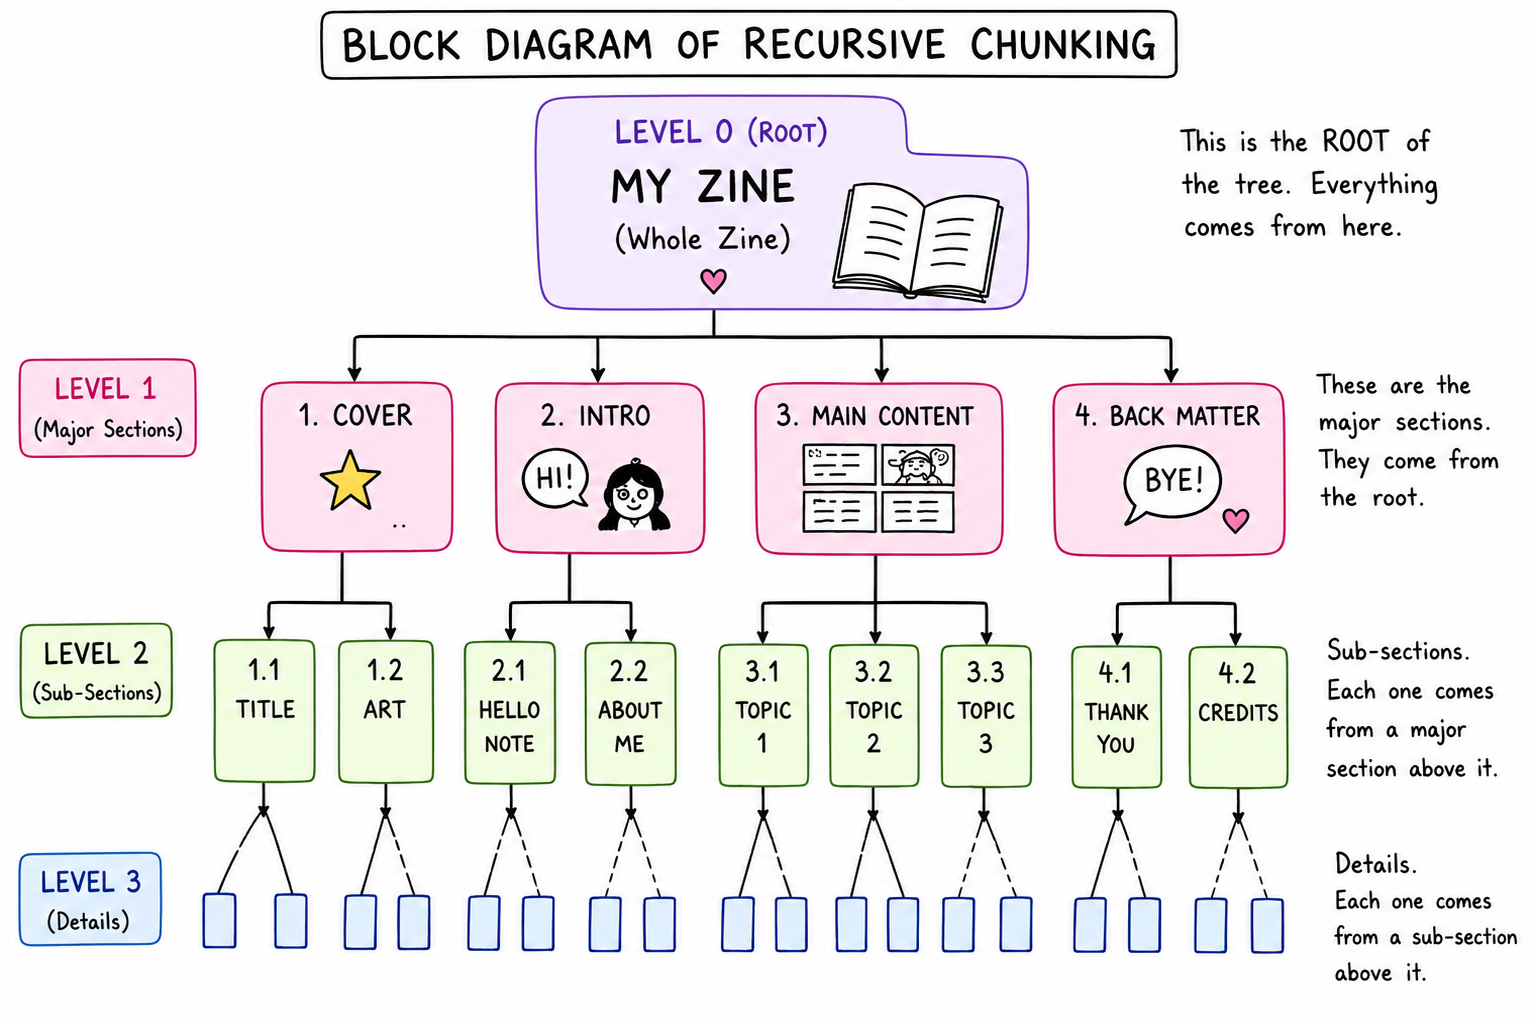

In [ ]:
def chunk_recursive(text: str, chunk_size: int = 500, overlap: int = 80) -> List[str]:
    """
    LangChain RecursiveCharacterTextSplitter.
    Tries paragraph -> newline -> sentence -> word -> character in order,
    preserving natural boundaries as much as possible.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        separators=['\n\n', '\n', '. ', '! ', '? ', ' ', ''],
        length_function=len,
    )
    return splitter.split_text(text)


chunks_recursive = chunk_recursive(raw_text, chunk_size=500, overlap=80)
print_chunks(chunks_recursive, 'Recursive Character (size=500, overlap=80)')



----------------------------------------------------------------------
  Strategy      : Recursive Character (size=500, overlap=80)
  Total chunks  : 28
  Avg chars     : 384
----------------------------------------------------------------------

  [Chunk 1]
    General English
     Grammar, Vocabulary and Communication
    Topics Covered:
     Parts of Speech
     Sentence Structure
     Punctuation
     Vocabulary Building
     Reading Comprehension
     Writing Skills
     Grammar Rules
     Essay Writing
     Common Mistakes and How to Fix Them

  [Chunk 2]
    Chapter 1: Parts of Speech
    Every word in the English language belongs to one of eight parts of speech. Understanding these is
    the foundation of good grammar.
    The Eight Parts of Speech
    1. Noun – Names a person, place, thing, or idea. (dog, London, happiness)
    2. Pronoun – Replaces a noun to avoid repetition. (he, she, it, they)
    3. Verb – Expresses action or state of being. (run, is, seem, crea

###3. Token-Based Chunking

In [ ]:
def chunk_by_tokens(
    text: str,
    max_tokens: int = 150,
    overlap_tokens: int = 20,
    encoding_name: str = 'cl100k_base',
) -> List[str]:
    """
    Split on tiktoken token boundaries instead of character counts.
    More accurate for LLM context budgets.
    cl100k_base matches GPT-4 / text-embedding-3-small.
    """
    enc = tiktoken.get_encoding(encoding_name)
    tokens = enc.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        chunks.append(enc.decode(tokens[start:end]))
        start += max_tokens - overlap_tokens
    return chunks


chunks_token = chunk_by_tokens(raw_text, max_tokens=150, overlap_tokens=20)
print_chunks(chunks_token, 'Token-Based (max=150 tokens, overlap=20)')


----------------------------------------------------------------------
  Strategy      : Token-Based (max=150 tokens, overlap=20)
  Total chunks  : 18
  Avg chars     : 640
----------------------------------------------------------------------

  [Chunk 1]
    General English
     Grammar, Vocabulary and Communication
    Topics Covered:
     Parts of Speech
     Sentence Structure
     Punctuation
     Vocabulary Building
     Reading Comprehension
     Writing Skills
     Grammar Rules
     Essay Writing
     Common Mistakes and How to Fix Them

    Chapter 1: Parts of Speech
    Every word in the English language belongs to one of eight parts of speech. Understanding these is
    the foundation of good grammar.
    The Eight Parts of Speech
    1. Noun – Names a person, place, thing, or idea. (dog, London, happiness)
    2. Pronoun – Replaces a noun to avoid repetition. (he, she, it, they)
    3. Verb – Expr
    ... (truncated)

  [Chunk 2]
    repetition. (he, she, it, th

###4. Sentence-Based Chunking

In [ ]:
def chunk_by_sentences(
    text: str,
    sentences_per_chunk: int = 5,
    overlap_sentences: int = 1,
) -> List[str]:
    """
    Tokenize into sentences using NLTK, then group N sentences per chunk.
    Chunks always end at sentence boundaries, preserving grammatical coherence.
    """
    sentences = nltk.sent_tokenize(text)
    chunks = []
    start = 0
    while start < len(sentences):
        end = min(start + sentences_per_chunk, len(sentences))
        chunks.append(' '.join(sentences[start:end]))
        start += sentences_per_chunk - overlap_sentences
    return chunks


chunks_sentence = chunk_by_sentences(raw_text, sentences_per_chunk=5, overlap_sentences=1)
print_chunks(chunks_sentence, 'Sentence-Based (5 sentences, 1 overlap)')


----------------------------------------------------------------------
  Strategy      : Sentence-Based (5 sentences, 1 overlap)
  Total chunks  : 40
  Avg chars     : 300
----------------------------------------------------------------------

  [Chunk 1]
    General English
     Grammar, Vocabulary and Communication
    Topics Covered:
     Parts of Speech
     Sentence Structure
     Punctuation
     Vocabulary Building
     Reading Comprehension
     Writing Skills
     Grammar Rules
     Essay Writing
     Common Mistakes and How to Fix Them

    Chapter 1: Parts of Speech
    Every word in the English language belongs to one of eight parts of speech. Understanding these is
    the foundation of good grammar. The Eight Parts of Speech
    1. Noun – Names a person, place, thing, or idea. (dog, London, happiness)
    2.

  [Chunk 2]
    (dog, London, happiness)
    2. Pronoun – Replaces a noun to avoid repetition. (he, she, it, they)
    3. Verb – Expresses action or state 

###5. Semantic Chunking

In [ ]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))


def embed_texts_batch(texts: List[str], batch_size: int = 100) -> List[np.ndarray]:
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        response = client.embeddings.create(model=EMBED_MODEL, input=batch)
        embeddings.extend([np.array(item.embedding) for item in response.data])
    return embeddings


def chunk_semantic(
    text: str,
    similarity_threshold: float = 0.75,
    min_chunk_sentences: int = 2,
    max_chunk_sentences: int = 15,
) -> List[str]:
    """
    Semantic chunking via sentence-level embedding similarity.

    Algorithm:
      1. Tokenize text into sentences.
      2. Embed each sentence with text-embedding-3-small.
      3. Compute cosine similarity between consecutive sentence pairs.
      4. Insert a chunk boundary when similarity < threshold
         or when the chunk exceeds max_chunk_sentences.
    """
    sentences = nltk.sent_tokenize(text)
    if not sentences:
        return []

    print(f'  Embedding {len(sentences)} sentences for semantic analysis ...')
    embeddings = embed_texts_batch(sentences)

    similarities = [
        cosine_similarity(embeddings[i], embeddings[i + 1])
        for i in range(len(embeddings) - 1)
    ]

    chunks = []
    current = [sentences[0]]

    for i, sim in enumerate(similarities):
        next_sentence = sentences[i + 1]
        boundary = (
            sim < similarity_threshold
            or len(current) >= max_chunk_sentences
        )
        if boundary and len(current) >= min_chunk_sentences:
            chunks.append(' '.join(current))
            current = [next_sentence]
        else:
            current.append(next_sentence)

    if current:
        chunks.append(' '.join(current))

    return chunks


print('Running semantic chunking (one OpenAI API call per sentence batch)...')
chunks_semantic = chunk_semantic(raw_text, similarity_threshold=0.75)
print_chunks(chunks_semantic, 'Semantic (cosine similarity, threshold=0.75)')

Running semantic chunking (one OpenAI API call per sentence batch)...
  Embedding 159 sentences for semantic analysis ...

----------------------------------------------------------------------
  Strategy      : Semantic (cosine similarity, threshold=0.75)
  Total chunks  : 79
  Avg chars     : 125
----------------------------------------------------------------------

  [Chunk 1]
    General English
     Grammar, Vocabulary and Communication
    Topics Covered:
     Parts of Speech
     Sentence Structure
     Punctuation
     Vocabulary Building
     Reading Comprehension
     Writing Skills
     Grammar Rules
     Essay Writing
     Common Mistakes and How to Fix Them

    Chapter 1: Parts of Speech
    Every word in the English language belongs to one of eight parts of speech. Understanding these is
    the foundation of good grammar.

  [Chunk 2]
    The Eight Parts of Speech
    1. Noun – Names a person, place, thing, or idea.

  [Chunk 3]
    (dog, London, happiness)
  

###6. Strategy Comparison Summary

In [ ]:
all_strategies = {
    'Fixed-Size Character' : chunks_fixed,
    'Recursive Character'  : chunks_recursive,
    'Token-Based'          : chunks_token,
    'Sentence-Based'       : chunks_sentence,
    'Semantic'             : chunks_semantic,
}

print(f"{'Strategy':<28} {'Chunks':>8} {'Avg Chars':>12} {'Min':>8} {'Max':>8}")
print('-' * 68)
for name, chunks in all_strategies.items():
    sizes = [len(c) for c in chunks]
    print(
        f"{name:<28} {len(chunks):>8,}"
        f" {sum(sizes)/len(sizes):>12,.0f}"
        f" {min(sizes):>8,}"
        f" {max(sizes):>8,}"
    )

Strategy                       Chunks    Avg Chars      Min      Max
--------------------------------------------------------------------
Fixed-Size Character               23          479       32      500
Recursive Character                28          384       41      493
Token-Based                        18          640      116      747
Sentence-Based                     40          300       83      523
Semantic                           79          125        9      415


#**LangGraph**


In [1]:
!pip install -q langgraph langchain-core langchain-openai python-dotenv grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00


In [2]:
import os
from getpass import getpass

print("🔐 Enter your OpenAI API Key")
api_key = getpass("OpenAI API Key: ")

os.environ["OPENAI_API_KEY"] = api_key

🔐 Enter your OpenAI API Key
OpenAI API Key: ··········


In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-4o-mini",  # or gpt-4o
    temperature=0.7
)

print("✅ OpenAI LLM Initialized")

✅ OpenAI LLM Initialized


### **WORKFLOW 1 — BASIC LINEAR FLOW**

In [17]:
from typing import TypedDict
from datetime import datetime
from langgraph.graph import StateGraph, START, END

class BasicState(TypedDict):
    topic: str
    research: str
    summary: str
    final_output: str


def research_node(state: BasicState):
    response = llm.invoke(f"Give 3 key facts about {state['topic']}")
    return {**state, "research": response.content}


def summarize_node(state: BasicState):
    response = llm.invoke(f"Summarize in 2 sentences: {state['research']}")
    return {**state, "summary": response.content}


def final_output_node(state: BasicState):
    return {
        **state,
        "final_output": f"""
📘 REPORT
Topic: {state['topic']}

Research:
{state['research']}

Summary:
{state['summary']}

Generated: {datetime.now()}
"""
    }


def create_basic_workflow():
    workflow = StateGraph(BasicState)

    workflow.add_node("research", research_node)
    workflow.add_node("summarize", summarize_node)
    workflow.add_node("final_output", final_output_node)

    workflow.add_edge(START, "research")
    workflow.add_edge("research", "summarize")
    workflow.add_edge("summarize", "final_output")
    workflow.add_edge("final_output", END)

    return workflow.compile()

In [5]:
basic_app = create_basic_workflow()

result = basic_app.invoke({
    "topic": "Artificial Intelligence",
    "research": "",
    "summary": "",
    "final_output": ""
})

print(result["final_output"])


📘 REPORT
Topic: Artificial Intelligence

Research:
Sure! Here are three key facts about Artificial Intelligence (AI):

1. **Definition and Types**: AI refers to the simulation of human intelligence in machines that are programmed to think and learn. There are two main types of AI: narrow AI, which is designed for specific tasks (like facial recognition or language translation), and general AI, which would have the ability to understand, learn, and apply intelligence across a wide range of tasks, similar to human cognitive abilities.

2. **Machine Learning and Deep Learning**: A significant subset of AI is machine learning, which involves algorithms that enable computers to learn from and make predictions based on data. Deep learning, a further subset of machine learning, uses neural networks with many layers (hence "deep") to analyze complex data patterns, enabling advancements in areas like image and speech recognition.

3. **Applications and Impact**: AI is increasingly being integr

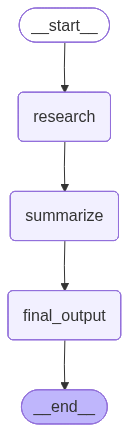

In [6]:
from IPython.display import Image

graph = basic_app.get_graph()
display(Image(graph.draw_mermaid_png()))

### **WORKFLOW 2 — PARALLEL PROCESSING**

In [10]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

def pick_first_value(a: str, b: str) -> str:
    return a


class ParallelState(TypedDict):
    topic: Annotated[str, pick_first_value]
    research: str
    creative: str
    analysis: str
    final_report: str


def research_node(state: ParallelState):
    res = llm.invoke(f"Research detailed facts about {state['topic']}")
    return {"research": res.content}


def creative_node(state: ParallelState):
    res = llm.invoke(f"Write engaging content about {state['topic']}")
    return {"creative": res.content}


def analysis_node(state: ParallelState):
    res = llm.invoke(f"Analyze pros, cons, and future of {state['topic']}")
    return {"analysis": res.content}


def final_report_node(state: ParallelState):
    return {
        "final_report": f"""
🌍 FINAL REPORT — {state['topic']}

Research:
{state['research'][:300]}

Creative:
{state['creative'][:300]}

Analysis:
{state['analysis'][:300]}
"""
    }


def create_parallel_workflow():
    workflow = StateGraph(ParallelState)

    workflow.add_node("research", research_node)
    workflow.add_node("creative", creative_node)
    workflow.add_node("analysis", analysis_node)
    workflow.add_node("final_report", final_report_node)

    workflow.add_edge(START, "research")

    workflow.add_edge("research", "creative")
    workflow.add_edge("research", "analysis")

    workflow.add_edge("creative", "final_report")
    workflow.add_edge("analysis", "final_report")

    workflow.add_edge("final_report", END)

    return workflow.compile()




In [11]:
parallel_app = create_parallel_workflow()

result = parallel_app.invoke({
    "topic": "Renewable Energy",
    "research": "",
    "creative": "",
    "analysis": "",
    "final_report": ""
})

print(result["final_report"])


🌍 FINAL REPORT — 

Research:
It seems like your request is incomplete. Could you please specify the topic or subject you would like detailed facts about? This will help me provide you with the most relevant information.

Creative:
Sure! However, it seems like your message was cut off. Could you please provide more details or specify the topic you’d like me to write about? Whether it's a specific subject, theme, or type of content (like an article, blog post, or story), I'd be happy to help!

Analysis:
It seems like your message got cut off. Could you please specify what topic or subject you'd like me to analyze in terms of pros, cons, and future? This could be anything from a technology, a business model, an environmental issue, etc. Let me know so I can assist you effectively!



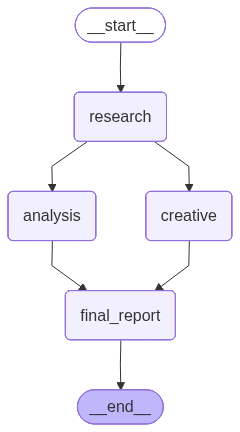

In [12]:
display(Image(parallel_app.get_graph().draw_mermaid_png()))

### **WORKFLOW 3 — CONDITIONAL BRANCHING**

In [13]:
class ConditionalState(TypedDict):
    query: str
    query_type: str
    response: str


def classify_node(state: ConditionalState):
    res = llm.invoke(
        f"Classify this as technical, creative, or general: {state['query']}"
    )
    return {**state, "query_type": res.content.strip().lower()}


def technical_node(state):
    res = llm.invoke(f"Provide detailed technical answer: {state['query']}")
    return {**state, "response": res.content}


def creative_node(state):
    res = llm.invoke(f"Provide creative response: {state['query']}")
    return {**state, "response": res.content}


def general_node(state):
    res = llm.invoke(f"Provide clear explanation: {state['query']}")
    return {**state, "response": res.content}


def route(state: ConditionalState):
    if "technical" in state["query_type"]:
        return "technical"
    elif "creative" in state["query_type"]:
        return "creative"
    else:
        return "general"


def create_conditional_workflow():
    workflow = StateGraph(ConditionalState)

    workflow.add_node("classify", classify_node)
    workflow.add_node("technical", technical_node)
    workflow.add_node("creative", creative_node)
    workflow.add_node("general", general_node)

    workflow.add_edge(START, "classify")

    workflow.add_conditional_edges(
        "classify",
        route,
        {
            "technical": "technical",
            "creative": "creative",
            "general": "general"
        }
    )

    workflow.add_edge("technical", END)
    workflow.add_edge("creative", END)
    workflow.add_edge("general", END)

    return workflow.compile()



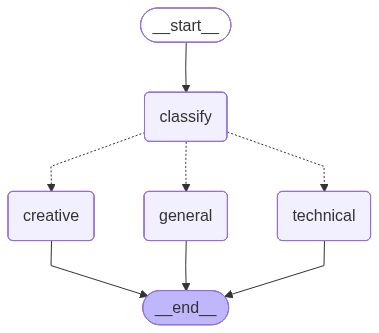

In [14]:
conditional_app = create_conditional_workflow()
display(Image(conditional_app.get_graph().draw_mermaid_png()))

### **WORKFLOW 4 — LOOP / SELF-IMPROVING AGENT**

In [15]:
class LoopState(TypedDict):
    query: str
    response: str
    score: int
    iteration: int


def generate_node(state: LoopState):
    res = llm.invoke(f"Answer: {state['query']}")
    return {**state, "response": res.content, "iteration": state["iteration"] + 1}


def evaluate_node(state: LoopState):
    res = llm.invoke(
        f"Score this answer 1-5 only:\n{state['response']}"
    )
    try:
        score = int(res.content.strip()[0])
    except:
        score = 3
    return {**state, "score": score}


def route_loop(state: LoopState):
    if state["score"] < 4 and state["iteration"] < 3:
        return "generate"
    return "end"


def create_loop_workflow():
    workflow = StateGraph(LoopState)

    workflow.add_node("generate", generate_node)
    workflow.add_node("evaluate", evaluate_node)

    workflow.add_edge(START, "generate")
    workflow.add_edge("generate", "evaluate")

    workflow.add_conditional_edges(
        "evaluate",
        route_loop,
        {
            "generate": "generate",
            "end": END
        }
    )

    return workflow.compile()

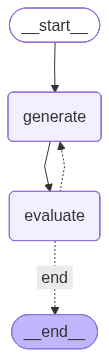

In [16]:
loop_app = create_loop_workflow()
display(Image(loop_app.get_graph().draw_mermaid_png()))

#**LangChain+RAG**

In [31]:

!pip install -q faiss-cpu langchain-openai langchain-community langgraph
import os
import pandas as pd
from typing import TypedDict, List
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from google.colab import userdata
from getpass import getpass
# 1. Setup Environment
os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
embeddings = OpenAIEmbeddings()
# 2. Load External Datasource (amazon.csv)
df = pd.read_csv('/content/sample_data/amazon.csv')
# Combine relevant fields for better search context
df['search_content'] = (
    "Product: " + df['product_name'].astype(str) +
    " | Category: " + df['category'].astype(str) +
    " | Price: " + df['discounted_price'].astype(str) +
    " | Rating: " + df['rating'].astype(str)
)

print(df['search_content'])

# Indexing the full dataset
documents = [Document(page_content=row['search_content'], metadata={"id": i}) for i, row in df.iterrows()]
# 3. Create Vector Store
vectorstore = FAISS.from_documents(documents, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
# 4. Define Graph State
class RAGState(TypedDict):
    query: str
    context: List[Document]
    generation: str
# 5. Define Nodes
def retrieve_node(state: RAGState):
    print("---RETRIEVING FROM FULL DATASET---")
    query = state["query"]
    docs = retriever.invoke(query)
    return {"context": docs}
def generate_node(state: RAGState):
    print("---GENERATING PROFESSIONAL RESPONSE---")
    context_text = "\n".join([f"- {d.page_content}" for d in state["context"]])
    prompt = (
        f"You are a helpful shopping assistant. Use the following product data to answer the user query.\n"
        f"Data:\n{context_text}\n\n"
        f"User Query: {state['query']}\n"
        f"Final Answer:"
    )
    response = llm.invoke(prompt)
    return {"generation": response.content}
# 6. Build LangGraph
builder = StateGraph(RAGState)
builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)
builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)
# 7. Compile and Run
rag_app = builder.compile()
# Execute query
result = rag_app.invoke({"query": "suggest me top 1 electronics item for me"})
print("\n---Result---")
print(result["generation"])


OpenAI API Key: ··········
0       Product: Wayona Nylon Braided USB to Lightning...
1       Product: Ambrane Unbreakable 60W / 3A Fast Cha...
2       Product: Sounce Fast Phone Charging Cable & Da...
3       Product: boAt Deuce USB 300 2 in 1 Type-C & Mi...
4       Product: Portronics Konnect L 1.2M Fast Chargi...
                              ...                        
1460    Product: Noir Aqua - 5pcs PP Spun Filter + 1 S...
1461    Product: Prestige Delight PRWO Electric Rice C...
1462    Product: Bajaj Majesty RX10 2000 Watts Heat Co...
1463    Product: Havells Ventil Air DSP 230mm Exhaust ...
1464    Product: Borosil Jumbo 1000-Watt Grill Sandwic...
Name: search_content, Length: 1465, dtype: object
---RETRIEVING FROM FULL DATASET---
---GENERATING PROFESSIONAL RESPONSE---

---Result---
Based on the product data, I recommend the **boAt Newly Launched Wave Electra with 1.81" HD Display** (Charcoal Black) priced at **₹2,999**. It has a solid rating of **4.1** and offers features lik